<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 12px;">
    <div style="width: 100%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis de Errores
        </h1>
    </div>
</div>

**Objetivo:** Entender **dónde y por qué** se equivoca el modelo LightGBM seleccionado en el notebook de experimentación. No buscamos solo contar errores, sino identificar patrones que nos digan si hay perfiles de pacientes sistemáticamente peor atendidos por el modelo.

Este análisis reutiliza las predicciones por fold de CV exportadas por `cardis_modelado.ipynb`, por lo que no requiere re-entrenar nada.


## 0. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

# ── Predicciones del modelo (exportadas por cardis_modelado.ipynb) ─────────────
df_pred = pd.read_csv('outputs/predicciones_lgbm_cv.csv')

# ── Datos originales con FE (para tener las variables clínicas) ───────────────
df_fe = pd.read_csv('../data/processed/cardio_risk_train_fe.csv')

# Unir predicciones con las features originales usando el índice
df = df_fe.loc[df_pred['idx']].copy().reset_index(drop=True)
df['y_true'] = df_pred['y_true'].values
df['y_pred'] = df_pred['y_pred'].values
df['y_proba'] = df_pred['y_proba'].values
df['fold'] = df_pred['fold'].values

# Clasificar cada predicción en uno de los cuatro resultados posibles
df['tipo'] = 'TN'  # True Negative (por defecto)
df.loc[(df['y_true'] == 1) & (df['y_pred'] == 1), 'tipo'] = 'TP'  # bien detectado
df.loc[(df['y_true'] == 0) & (df['y_pred'] == 1), 'tipo'] = 'FP'  # falsa alarma
df.loc[(df['y_true'] == 1) & (df['y_pred'] == 0), 'tipo'] = 'FN'  # no detectado
df['error'] = df['y_true'] != df['y_pred']

print(f"Total de predicciones: {len(df):,}")
print(f"\nDistribución de resultados:")
print(df['tipo'].value_counts().to_string())
print(f"\nTasa de error global: {df['error'].mean():.2%}")


Total de predicciones: 24,000

Distribución de resultados:
tipo
TN    16707
TP     4100
FP     2037
FN     1156

Tasa de error global: 13.30%


## 1. Matriz de confusión y cuantificación de errores

Lo primero es poner números concretos: ¿cuántos errores comete el modelo y de qué tipo son? En el contexto de CARDIS, no todos los errores pesan igual:

- **Falso Negativo (FN):** paciente de alto riesgo que el modelo clasifica como bajo riesgo. Es **el error clínicamente grave**, porque ese paciente no recibirá la intervención preventiva que necesita.
- **Falso Positivo (FP):** paciente de bajo riesgo clasificado como alto riesgo. Genera una alarma innecesaria — pruebas adicionales, ansiedad del paciente — pero al menos el paciente no pasa desapercibido.


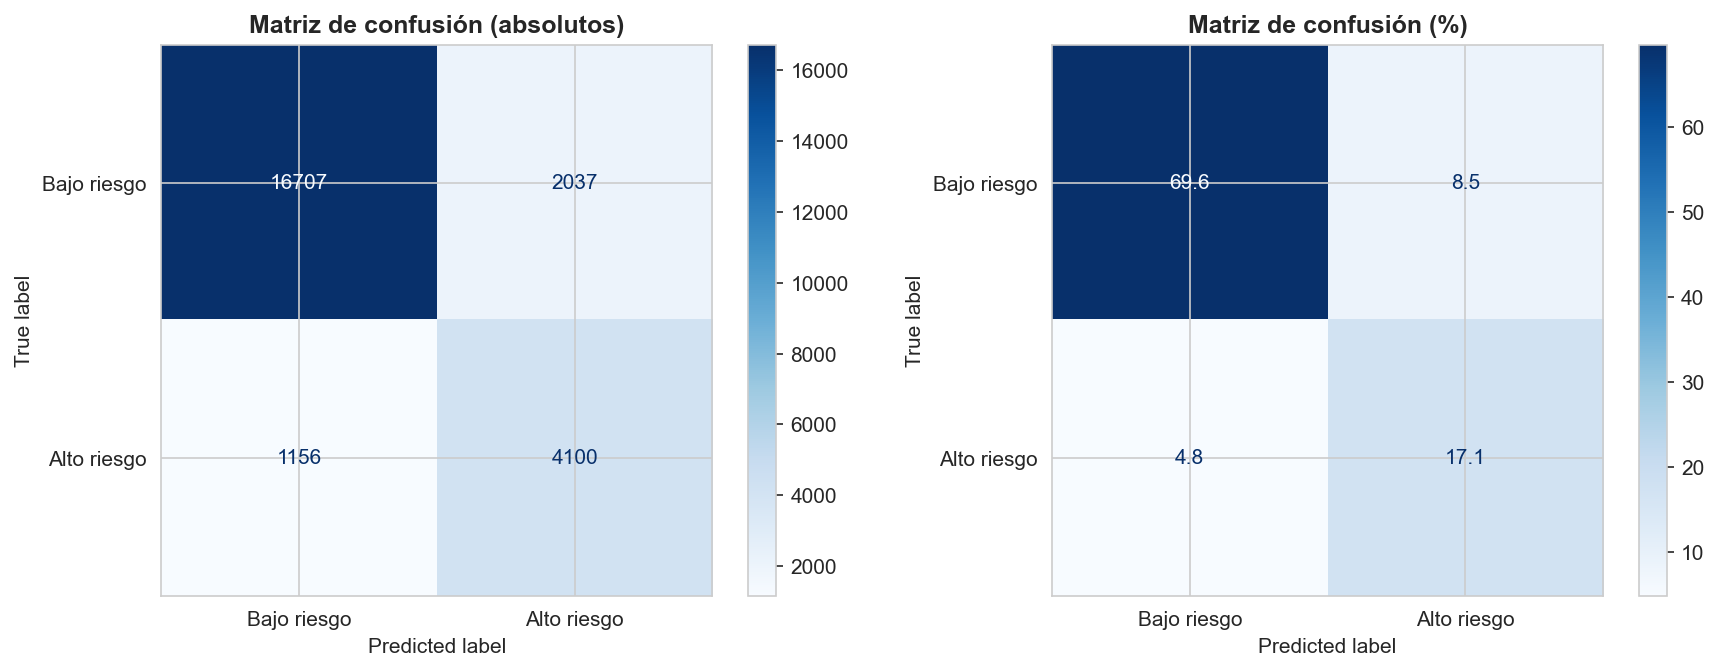

Verdaderos Negativos (TN): 16,707  — pacientes de bajo riesgo correctamente identificados
Verdaderos Positivos (TP): 4,100  — pacientes de alto riesgo correctamente detectados
Falsos Positivos (FP):     2,037  — alarmas falsas
Falsos Negativos (FN):     1,156  — pacientes de riesgo no detectados (error grave)

De los 5,256 pacientes realmente de alto riesgo, el modelo detecta 4,100 (78.0%).
De los 18,744 pacientes de bajo riesgo, clasifica mal a 2,037 (10.9%).


In [2]:
# ── Matriz de confusión agregada sobre los 5 folds ────────────────────────────
cm = confusion_matrix(df['y_true'], df['y_pred'], labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: valores absolutos
disp = ConfusionMatrixDisplay(cm, display_labels=['Bajo riesgo', 'Alto riesgo'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de confusión (absolutos)', fontweight='bold')

# Panel derecho: porcentajes sobre el total
cm_pct = cm / cm.sum() * 100
disp2 = ConfusionMatrixDisplay(cm_pct, display_labels=['Bajo riesgo', 'Alto riesgo'])
disp2.plot(ax=axes[1], cmap='Blues', values_format='.1f')
axes[1].set_title('Matriz de confusión (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn:,}  — pacientes de bajo riesgo correctamente identificados")
print(f"Verdaderos Positivos (TP): {tp:,}  — pacientes de alto riesgo correctamente detectados")
print(f"Falsos Positivos (FP):     {fp:,}  — alarmas falsas")
print(f"Falsos Negativos (FN):     {fn:,}  — pacientes de riesgo no detectados (error grave)")
print(f"\nDe los {fn+tp:,} pacientes realmente de alto riesgo, el modelo detecta {tp:,} ({tp/(fn+tp):.1%}).")
print(f"De los {fp+tn:,} pacientes de bajo riesgo, clasifica mal a {fp:,} ({fp/(fp+tn):.1%}).")


El modelo acierta en el **86,7%** (69,6% + 17,1%) de los casos, pero esa cifra global esconde el desequilibrio entre tipos de error. Los **1.156 falsos negativos** son el problema principal: representan pacientes de alto riesgo cardiovascular que el sistema no identificaría, lo que en la práctica significaría perder la oportunidad de intervención preventiva. Los **2.037 falsos positivos**, aunque más numerosos, tienen un coste clínico menor: generan pruebas adicionales pero no dejan pasar un riesgo real.

Dicho de forma más directa: de cada 100 pacientes que realmente tienen alto riesgo, el modelo detecta a 78 y deja pasar a 22. Y de cada 100 que no tienen riesgo, etiqueta erróneamente a 11 como si lo tuvieran. El primer ratio (el *recall*, que mide la capacidad del modelo para identificar correctamente los casos positivos) es el que más nos preocupa clínicamente.


## 2. ¿Dónde se equivoca? Análisis por edad

La edad es el factor de riesgo más predictivo del dataset y, a la vez, el eje principal de equidad identificado en el Hito 2. Sabemos que los pacientes menores de 56 años tienen la glucosa en ayunas ausente en más del 75% de los casos, lo que reduce la información disponible para el modelo en ese subgrupo. La pregunta es: ¿se traduce esto en peor rendimiento?


In [3]:
# ── Crear franjas de edad (mismas que en cardis_equidad.ipynb del Hito 2) ─────
bins = [30, 40, 50, 56, 65, 75, 84]
labels = ['30-39', '40-49', '50-55', '56-64', '65-74', '75-84']
df['franja_edad'] = pd.cut(df['edad'], bins=bins, labels=labels, include_lowest=True)

# ── Métricas por franja ───────────────────────────────────────────────────────
metricas_edad = []
for franja in labels:
    sub = df[df['franja_edad'] == franja]
    n = len(sub)
    n_pos = sub['y_true'].sum()
    
    if n_pos > 0 and n_pos < n:
        f1 = f1_score(sub['y_true'], sub['y_pred'])
        rec = recall_score(sub['y_true'], sub['y_pred'])
        prec = precision_score(sub['y_true'], sub['y_pred']) if sub['y_pred'].sum() > 0 else 0
    else:
        f1, rec, prec = 0, 0, 0
    
    tasa_error = sub['error'].mean()
    n_fn = ((sub['y_true'] == 1) & (sub['y_pred'] == 0)).sum()
    n_fp = ((sub['y_true'] == 0) & (sub['y_pred'] == 1)).sum()
    
    metricas_edad.append({
        'Franja': franja, 'N': n, 'Prevalencia': f"{n_pos/n:.1%}",
        'F1': f"{f1:.3f}", 'Recall': f"{rec:.3f}", 'Precision': f"{prec:.3f}",
        'FN': n_fn, 'FP': n_fp, 'Tasa error': f"{tasa_error:.1%}"
    })

df_edad = pd.DataFrame(metricas_edad)
print("RENDIMIENTO POR FRANJA DE EDAD")
print("="*90)
print(df_edad.to_string(index=False))


RENDIMIENTO POR FRANJA DE EDAD
Franja    N Prevalencia    F1 Recall Precision  FN  FP Tasa error
 30-39 4751        3.3% 0.456  0.405     0.520  94  59       3.2%
 40-49 4536        6.9% 0.506  0.500     0.511 157 150       6.8%
 50-55 2633       13.0% 0.618  0.662     0.579 116 165      10.7%
 56-64 3826       22.5% 0.665  0.720     0.618 241 382      16.3%
 65-74 4315       35.9% 0.728  0.813     0.659 289 653      21.8%
 75-84 3939       51.6% 0.800  0.873     0.738 259 628      22.5%


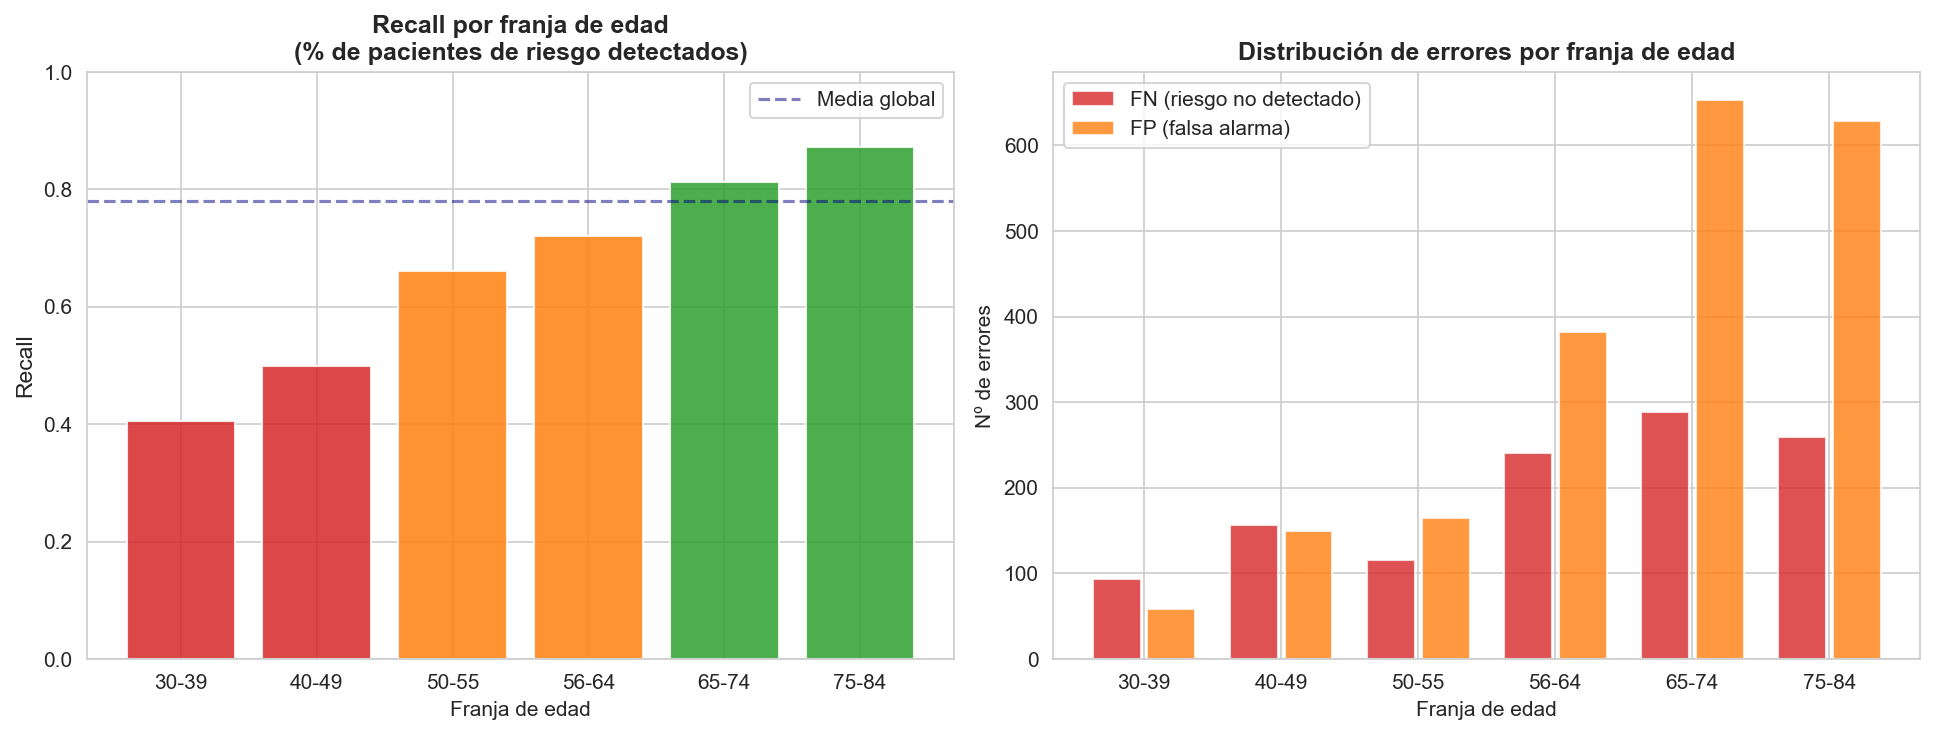

In [4]:
# ── Visualización: recall y distribución de errores por franja ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: recall por franja
recalls = [float(r) for r in df_edad['Recall']]
colors = ['#d62728' if r < 0.6 else '#ff7f0e' if r < 0.75 else '#2ca02c' for r in recalls]
axes[0].bar(labels, recalls, color=colors, edgecolor='white', alpha=0.85)
axes[0].axhline(y=recall_score(df['y_true'], df['y_pred']), color='navy',
                linestyle='--', alpha=0.5, label='Media global')
axes[0].set_ylabel('Recall', fontsize=11)
axes[0].set_xlabel('Franja de edad')
axes[0].set_title('Recall por franja de edad\n(% de pacientes de riesgo detectados)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Panel derecho: FN y FP por franja
fn_por_franja = [int(x) for x in df_edad['FN']]
fp_por_franja = [int(x) for x in df_edad['FP']]
x = np.arange(len(labels))
axes[1].bar(x - 0.2, fn_por_franja, 0.35, label='FN (riesgo no detectado)', color='#d62728', alpha=0.8)
axes[1].bar(x + 0.2, fp_por_franja, 0.35, label='FP (falsa alarma)', color='#ff7f0e', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Nº de errores')
axes[1].set_xlabel('Franja de edad')
axes[1].set_title('Distribución de errores por franja de edad', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig_errores_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()


Este es, probablemente, el hallazgo más importante del análisis de errores. El recall del modelo presenta un **gradiente dramático con la edad**:

- En pacientes de **30-39 años**, el modelo solo detecta al **40%** de los de alto riesgo. De cada 5 pacientes jóvenes con riesgo real, se le escapan 3.
- En pacientes de **40-49 años**, el recall sube apenas al **50%**: sigue siendo como tirar una moneda al aire.
- A partir de los **56-64 años** el rendimiento ya es razonable (72%), y en **75-84 años** alcanza el **87%**, por encima de la media global.

Este patrón conecta directamente con lo que descubrimos en el análisis de equidad del Hito 2: los pacientes menores de 56 años carecen de glucosa en ayunas (un predictor moderado del riesgo) en más del 75% de los casos. El modelo tiene, literalmente, menos información para decidir sobre ellos. Además, los pacientes jóvenes de alto riesgo son inherentemente más difíciles de clasificar porque son "atípicos": no encajan en el perfil clásico de riesgo cardiovascular (personas mayores, con presión alta y colesterol elevado).

La distribución de errores por tipo también es reveladora. En las franjas jóvenes predominan los **FN** (pacientes no detectados), mientras que en las franjas mayores predominan los **FP** (falsas alarmas). Esto tiene sentido clínico: el modelo, al haber aprendido que la edad alta se asocia fuertemente con riesgo, tiende a sobre-predecir riesgo en mayores (más FP) y a infra-predecir en jóvenes (más FN).

Este es un hallazgo relevante para el diseño de CARDIS: el sistema debería incluir una **advertencia explícita** al médico cuando evalúe a pacientes jóvenes, indicando que la predicción tiene menor fiabilidad en ese subgrupo.


## 3. ¿Con qué confianza se equivoca?

No es lo mismo equivocarse con una probabilidad del 49% (un caso límite donde el modelo duda) que con una del 10% (el modelo estaba convencido y aun así falló). Si los errores se concentran en la zona de incertidumbre, ajustar el *threshold* podría corregirlos. Si el modelo se equivoca con alta confianza, el problema es más profundo.


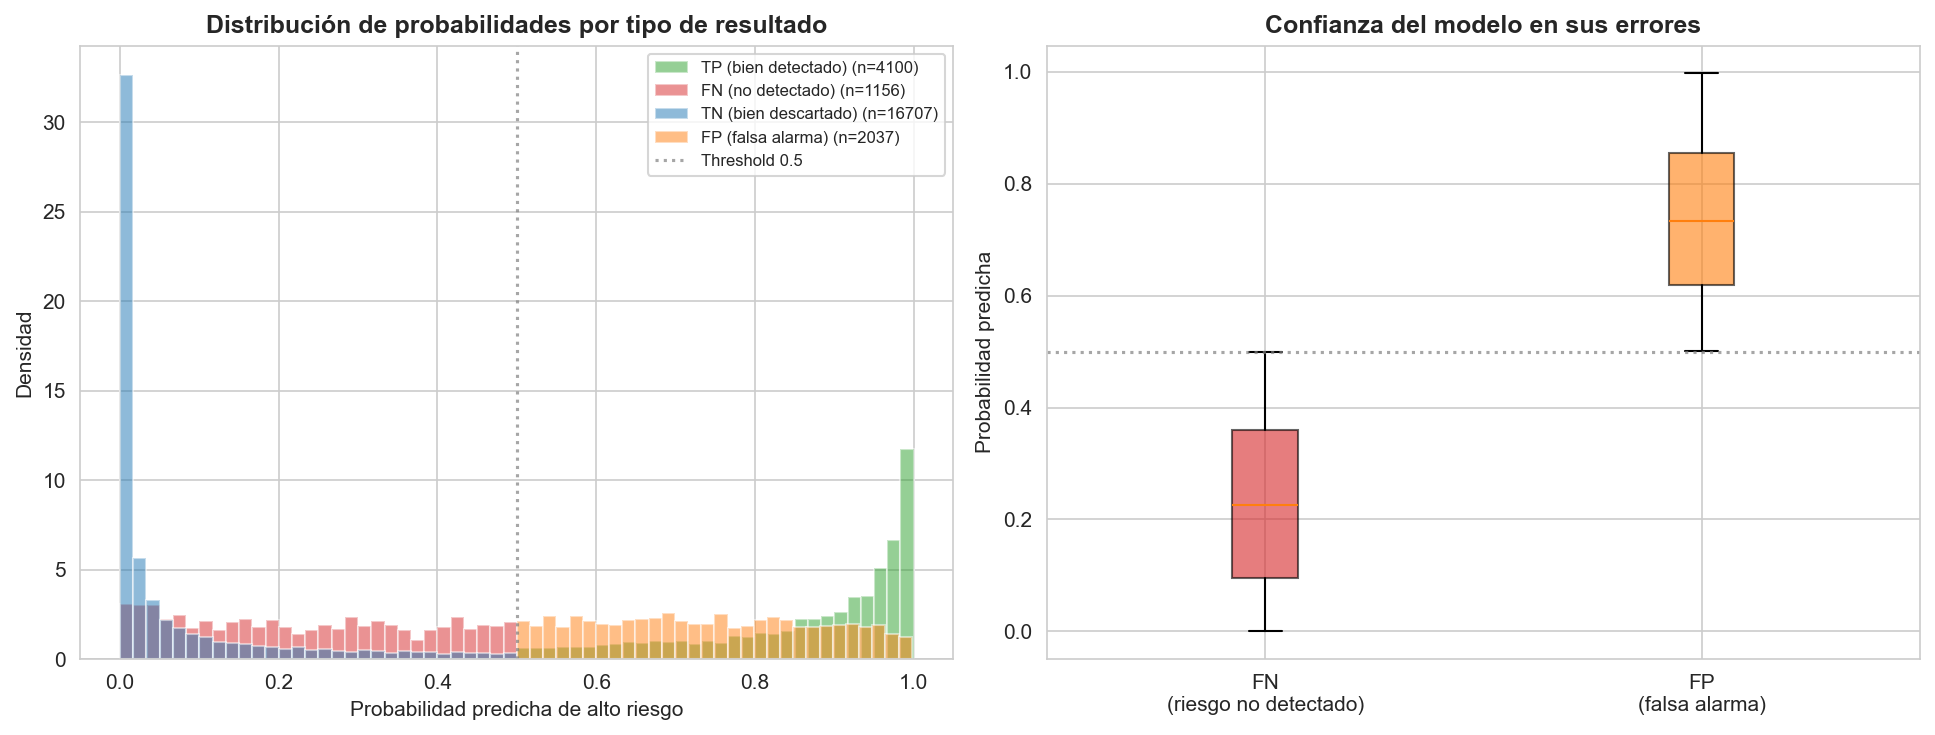

Falsos Negativos — probabilidad media: 0.233 (mediana: 0.225)
Falsos Positivos — probabilidad media: 0.738 (mediana: 0.734)

FN con probabilidad > 0.4 (casi detectados): 224 de 1156 (19.4%)
FP con probabilidad < 0.6 (baja confianza):   430 de 2037 (21.1%)


In [5]:
# ── Distribución de probabilidades por tipo de resultado ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: histograma de probabilidades
for tipo, color, label in [('TP', '#2ca02c', 'TP (bien detectado)'),
                            ('FN', '#d62728', 'FN (no detectado)'),
                            ('TN', '#1f77b4', 'TN (bien descartado)'),
                            ('FP', '#ff7f0e', 'FP (falsa alarma)')]:
    subset = df[df['tipo'] == tipo]['y_proba']
    axes[0].hist(subset, bins=30, alpha=0.5, label=f'{label} (n={len(subset)})',
                 color=color, density=True)
axes[0].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Threshold 0.5')
axes[0].set_xlabel('Probabilidad predicha de alto riesgo')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de probabilidades por tipo de resultado', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel derecho: boxplot de confianza en los errores
data_box = [df[df['tipo'] == 'FN']['y_proba'],
            df[df['tipo'] == 'FP']['y_proba']]
bp = axes[1].boxplot(data_box, tick_labels=['FN\n(riesgo no detectado)', 'FP\n(falsa alarma)'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('#d62728')
bp['boxes'][1].set_facecolor('#ff7f0e')
for box in bp['boxes']:
    box.set_alpha(0.6)
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.7)
axes[1].set_ylabel('Probabilidad predicha')
axes[1].set_title('Confianza del modelo en sus errores', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig_confianza_errores.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave
fn_proba = df[df['tipo'] == 'FN']['y_proba']
fp_proba = df[df['tipo'] == 'FP']['y_proba']
print(f"Falsos Negativos — probabilidad media: {fn_proba.mean():.3f} (mediana: {fn_proba.median():.3f})")
print(f"Falsos Positivos — probabilidad media: {fp_proba.mean():.3f} (mediana: {fp_proba.median():.3f})")
print(f"\nFN con probabilidad > 0.4 (casi detectados): {(fn_proba > 0.4).sum()} de {len(fn_proba)} ({(fn_proba > 0.4).mean():.1%})")
print(f"FP con probabilidad < 0.6 (baja confianza):   {(fp_proba < 0.6).sum()} de {len(fp_proba)} ({(fp_proba < 0.6).mean():.1%})")


Los resultados son claros y, en cierto modo, preocupantes. En el histograma del panel izquierdo se aprecia cómo los FN (en rojo) se reparten por toda la zona baja del eje de probabilidades, lejos de la línea punteada del threshold 0,5: no son casos frontera donde el modelo dude.

**Los falsos negativos son errores "seguros" del modelo.** La probabilidad media asignada a los FN es de apenas **0,233** (mediana: 0,225). El modelo no es que dude y se equivoque por poco: está bastante convencido de que estos pacientes son de bajo riesgo, y se equivoca. Solo el **19,4%** de los FN tiene una probabilidad superior a 0,4 (es decir, solo 224 de los 1.156 estaban cerca de ser detectados). El resto, más de 900 pacientes, están lejos de cualquier *threshold* razonable. El boxplot del panel derecho lo confirma: la caja roja (FN) tiene su mediana en 0,225, con los bigotes superiores rozando apenas el 0,4.

Esto tiene una implicación directa: **bajar el threshold no resolvería la mayoría de los FN**. Habría que bajar hasta niveles absurdos (por debajo de 0,25) para capturarlos, lo que dispararía los falsos positivos a niveles inaceptables.

**Los falsos positivos, en cambio, son errores de alta confianza.** La caja naranja del boxplot muestra una mediana de **0,734**, con el grueso de la distribución por encima de 0,6. El modelo cree firmemente que estos pacientes tienen riesgo alto, pero no lo tienen. Esto sugiere que hay perfiles de pacientes que "parecen" de alto riesgo según las variables disponibles (edad avanzada, ciertos valores clínicos) pero cuya etiqueta real es bajo riesgo, posiblemente porque factores protectores no capturados en el dataset (medicación, dieta, genética) los protegen.

La conclusión operativa es que los errores del modelo **no se corrigen fácilmente con ajustes de threshold ni de hiperparámetros**. Son errores estructurales, vinculados a la información disponible en el dataset. Para mejorarlos, necesitaríamos variables adicionales (sexo, medicación, marcadores inflamatorios) o un dataset más rico.


## 4. ¿Qué distingue a los errores? Perfil de los falsos negativos

Sabemos que hay 1.156 pacientes de alto riesgo que el modelo no detecta. ¿Qué tienen de diferente respecto a los 4.100 que sí detecta? Comparamos sus variables clínicas para construir un "retrato robot" del paciente que se le escapa al modelo.


In [6]:
# ── Comparar el perfil clínico de FN (no detectados) vs TP (detectados) ───────
vars_clinicas = ['edad', 'presion_media', 'ldl', 'glucosa_ayunas', 'imc',
                 'horas_actividad', 'fumador', 'antecedentes_familiares']
vars_clinicas = [v for v in vars_clinicas if v in df.columns]

df_tp = df[df['tipo'] == 'TP'][vars_clinicas]
df_fn = df[df['tipo'] == 'FN'][vars_clinicas]

# Tabla comparativa
comparacion = pd.DataFrame({
    'TP (detectados)': df_tp.mean(),
    'FN (no detectados)': df_fn.mean(),
    'Δ (FN - TP)': df_fn.mean() - df_tp.mean()
}).round(2)

print("PERFIL CLÍNICO: pacientes de alto riesgo detectados (TP) vs no detectados (FN)")
print("="*75)
print(comparacion.to_string())
print(f"\nN: {len(df_tp):,} TP vs {len(df_fn):,} FN")


PERFIL CLÍNICO: pacientes de alto riesgo detectados (TP) vs no detectados (FN)
                         TP (detectados)  FN (no detectados)  Δ (FN - TP)
edad                               71.08               62.81        -8.26
presion_media                     135.80              130.02        -5.78
ldl                               145.58              134.74       -10.84
glucosa_ayunas                    100.64               96.23        -4.41
imc                                26.23               25.10        -1.13
horas_actividad                     1.50                2.15         0.65
fumador                             0.49                0.39        -0.10
antecedentes_familiares             0.32                0.27        -0.05

N: 4,100 TP vs 1,156 FN


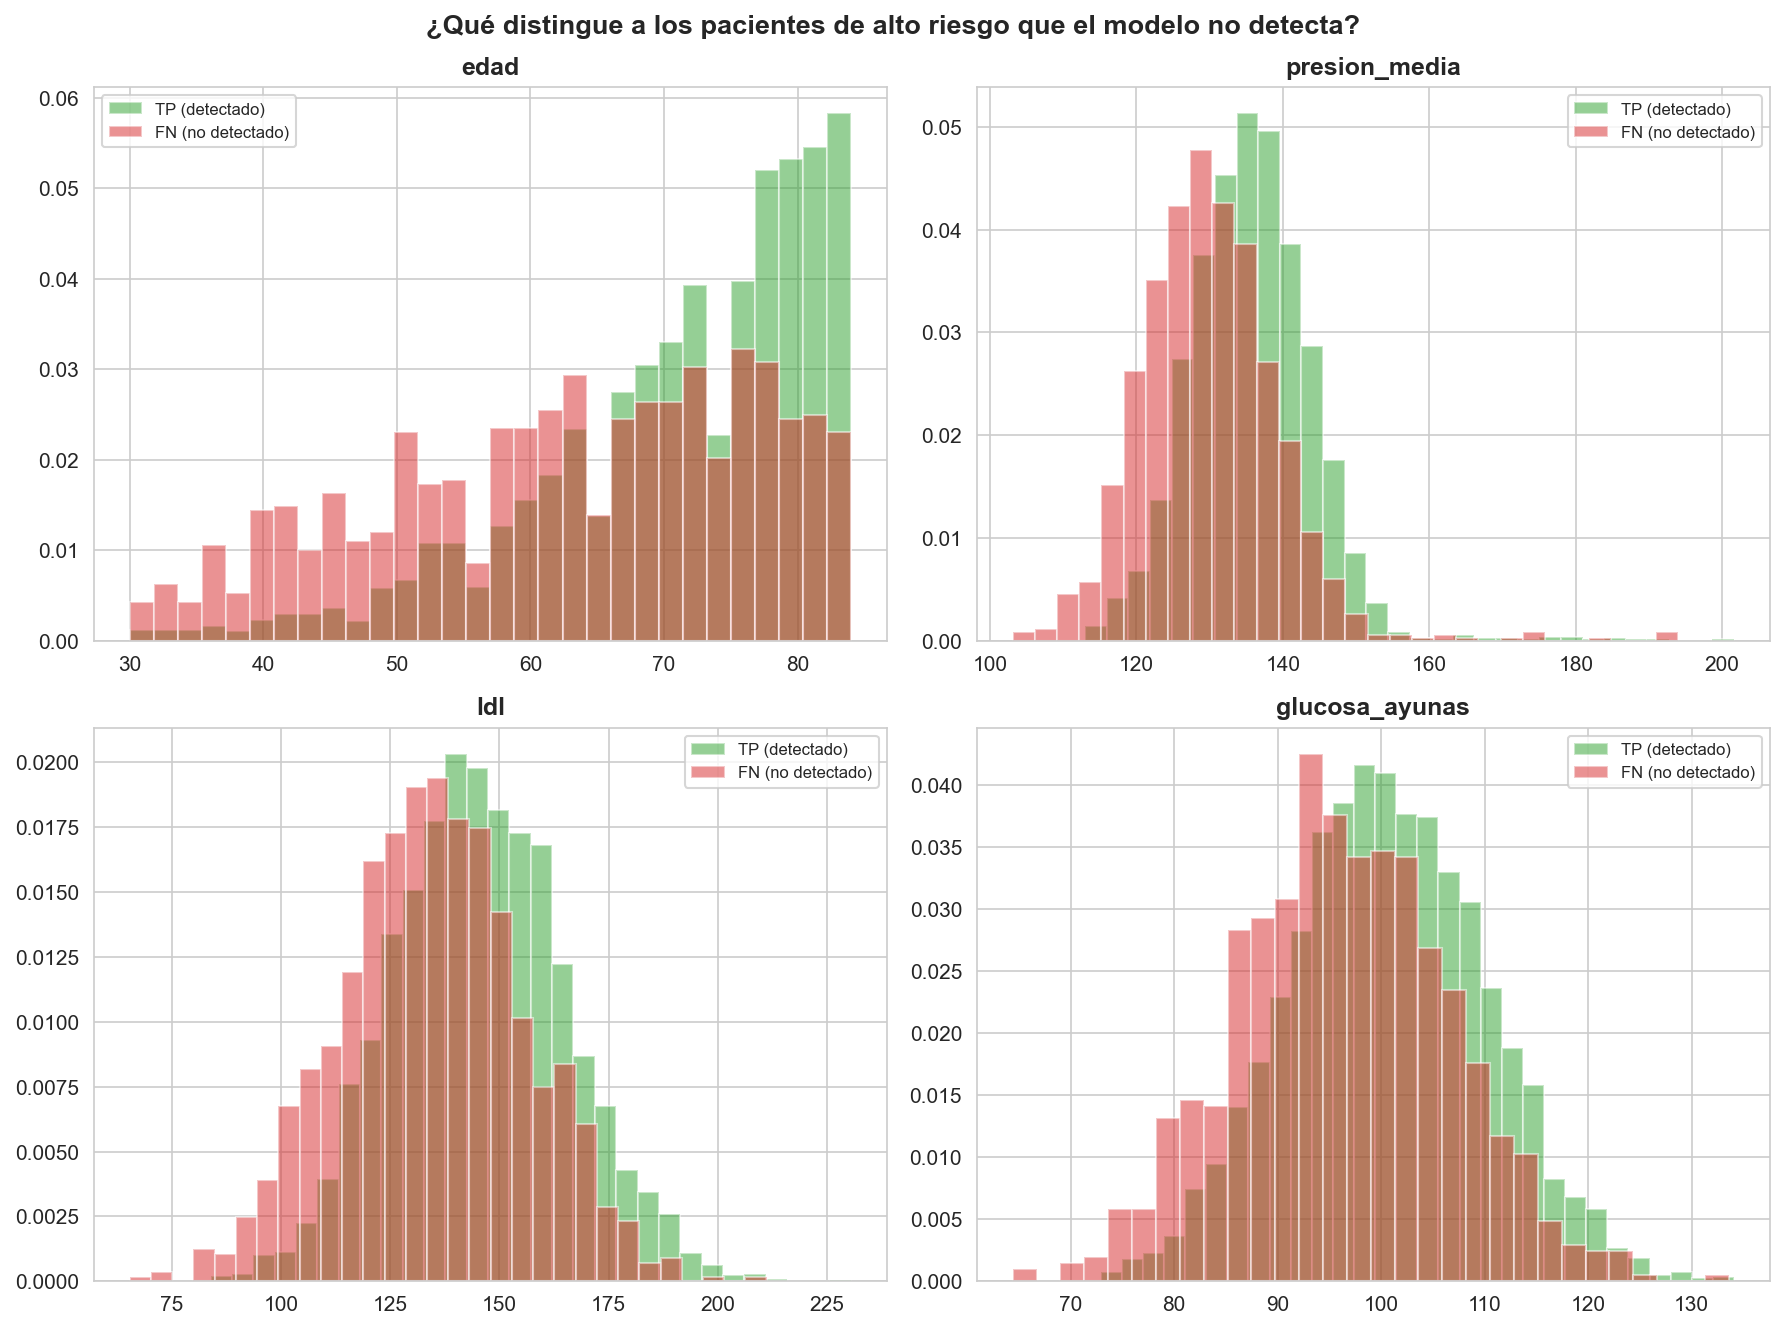

In [7]:
# ── Visualización: distribución de variables clave en FN vs TP ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
vars_plot = ['edad', 'presion_media', 'ldl', 'glucosa_ayunas']
vars_plot = [v for v in vars_plot if v in df.columns]

for ax, var in zip(axes.flatten(), vars_plot):
    for tipo, color, label in [('TP', '#2ca02c', 'TP (detectado)'),
                                ('FN', '#d62728', 'FN (no detectado)')]:
        data = df[df['tipo'] == tipo][var].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(var, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('¿Qué distingue a los pacientes de alto riesgo que el modelo no detecta?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_perfil_fn.png', dpi=150, bbox_inches='tight')
plt.show()


La tabla y las distribuciones revelan un patrón coherente. En los cuatro paneles de la figura, la distribución roja (FN) está sistemáticamente desplazada a la izquierda respecto a la verde (TP), lo que indica que los pacientes de alto riesgo que el modelo no detecta son, en comparación con los que sí detecta:

- **Más jóvenes:** 63 años de media frente a 71 en los TP. Es la diferencia más visible en el panel de edad (arriba izquierda), donde la masa roja se concentra en el rango 35-60 mientras que la verde domina en 65-84. Conecta directamente con el análisis por franjas de la sección anterior.
- **Con valores clínicos menos extremos:** LDL 11 puntos más bajo (135 vs 146), presión media 6 puntos más baja (130 vs 136), glucosa 4 puntos más baja (96 vs 101). En los paneles de presión y LDL el solapamiento es grande, pero el desplazamiento es consistente. En el panel de glucosa (abajo derecha), hay que tener en cuenta que muchos FN (pacientes jóvenes) tienen la glucosa imputada por mediana, por lo que refleja parcialmente el sesgo de imputación documentado en el Hito 2.
- **Más activos físicamente:** 2,15 horas/semana frente a 1,50 en los TP. La actividad física, un factor protector que el modelo ha aprendido bien, juega en su contra: al ser más activos, el modelo los descarta como de bajo riesgo.

En resumen, los FN son **pacientes de alto riesgo "atípicos"**: más jóvenes, con marcadores menos alarmantes y hábitos más saludables que el perfil clásico. Su riesgo elevado probablemente se debe a factores que el dataset no captura bien: predisposición genética, factores metabólicos no visibles en las variables disponibles, o condiciones que solo aparecen en las notas médicas de algunos registros.

Este perfil tiene implicaciones directas para el sistema CARDIS: precisamente los pacientes donde una detección temprana tendría mayor impacto (jóvenes con riesgo no evidente) son los que peor identifica el modelo.

## 5. Conclusiones

El análisis de errores revela que el modelo LightGBM de CARDIS no falla de forma aleatoria. Sus errores siguen un patrón claro: tiene dificultades sistemáticas con los **pacientes jóvenes de alto riesgo**, precisamente el subgrupo donde la prevención temprana tendría el mayor impacto clínico.

### ¿Por qué ocurre esto?

La raíz del problema no está en el modelo ni en sus hiperparámetros: está en los datos. Los pacientes jóvenes de alto riesgo son difíciles de detectar por tres razones que se refuerzan mutuamente:

1. **Menos información disponible:** la glucosa en ayunas, un predictor relevante, falta en más del 75% de los menores de 56 años.
2. **Perfil atípico:** sus valores clínicos (presión, LDL, IMC) son menos extremos que los de los pacientes mayores de riesgo. El modelo ha aprendido a asociar "valores extremos" con "alto riesgo", y estos pacientes no encajan en ese patrón.
3. **Baja prevalencia en su franja:** solo el 3-7% de los pacientes de 30-49 años tiene alto riesgo, frente al 50% en los de 75-84. El modelo tiene muchos menos ejemplos positivos para aprender en este subgrupo.

### ¿Es corregible?

Solo parcialmente, con los datos actuales. Ajustar el *threshold* no ayudaría: la mayoría de los FN reciben probabilidades muy bajas (mediana de 0,225), lejos de cualquier umbral razonable. Para mejorar realmente la detección en pacientes jóvenes sería necesario incorporar variables adicionales: el sexo (ausente en el dataset), marcadores inflamatorios, historial farmacológico o información genética.

### ¿Qué implica para CARDIS como sistema?

Este análisis refuerza una decisión de diseño del Hito 1: CARDIS no es un sistema de decisión automática, sino de **apoyo** al médico (*human-in-the-loop*). El modelo funciona bien para la mayoría de pacientes, pero tiene un punto ciego conocido que el profesional debe tener en cuenta. En la interfaz del sistema, esto podría traducirse en una advertencia visual cuando se evalúe a un paciente joven, informando al médico de que la predicción tiene menor fiabilidad en ese perfil y que debe complementarla con su juicio clínico.


## Declaración de uso de inteligencia artificial

Las decisiones analíticas, la interpretación de los resultados y las conclusiones de este notebook han sido realizadas íntegramente por los autores. La inteligencia artificial (Claude, Anthropic) se ha utilizado como apoyo en la generación de código para las visualizaciones y en la revisión del texto explicativo. Los autores asumen plena responsabilidad sobre el contenido.